# Practice 4.
## Objectives:
1. Do a simple Linear classifier
2. Deal with *colinearity*
3. Understand how the logistic regression works
4. Learn to clean up databases.

Aplication:
Data basse: Data set from the UCI Machine Learning Repository (http://archive.ics.uci.edu/ml)

Bank marketing prediction Data Set: http://archive.ics.uci.edu/ml/datasets/Bank+Marketing
Predict **has the client subscribed a term deposit? (binary: 'yes','no')**.

In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay



In [2]:
File = "bank-full.xls"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')

Filename with path: 
 c:\Users\Marcel\Uni\Master\MLEARN\MLEARN\Practicas\FourthPractice\Data\bank-full.xls


% Note in case of error, check if you have the library xlrd installed, and if not, install it with the following command:
pip install xlrd>=2.0.1

In [3]:
Data = pd.read_excel(Filename)
Data.head().T

,0,1,2,3,4
age,58,44,33,47,33
job,management,technician,entrepreneur,blue-collar,unknown
marital,married,single,married,married,single
education,tertiary,secondary,secondary,unknown,unknown
default,no,no,no,no,no
balance,2143,29,2,1506,1
housing,yes,yes,yes,yes,no
loan,no,no,yes,no,no
contact,unknown,unknown,unknown,unknown,unknown
day,5,5,5,5,5


### First take a glimpse of the numerical data

In [4]:
Data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.16,257.53,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.76,3.10,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.20,100.13,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.58,2.30,0.0,0.0,0.0,0.0,275.0


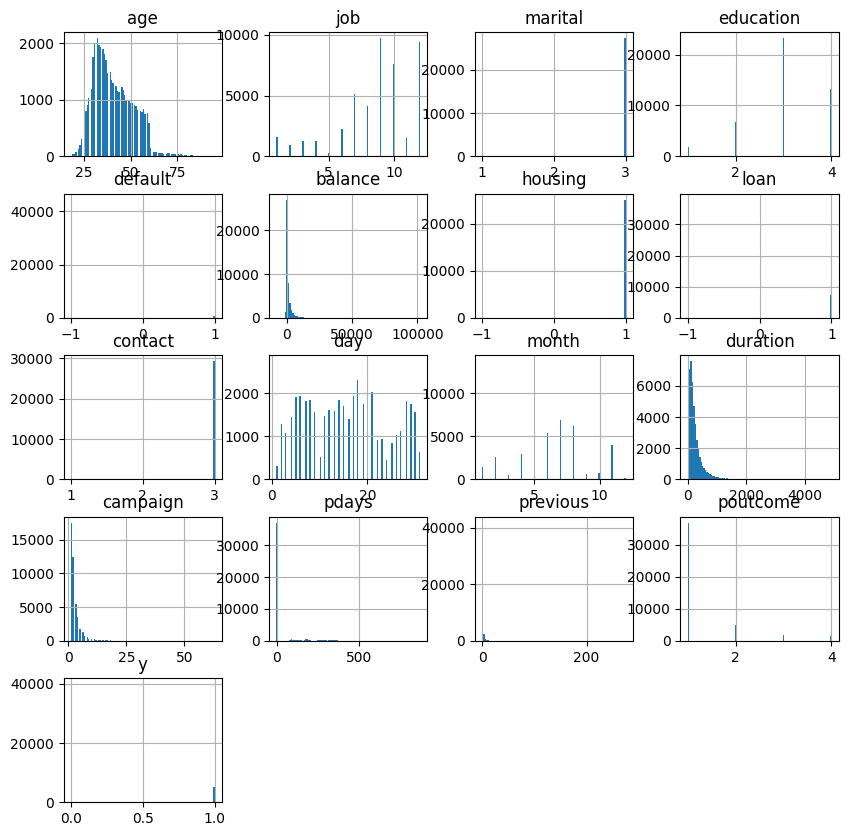

In [15]:
ax =Data.hist(figsize= (10,10),bins = 100)

Lets see if the follow up of the client "pdays" changes something


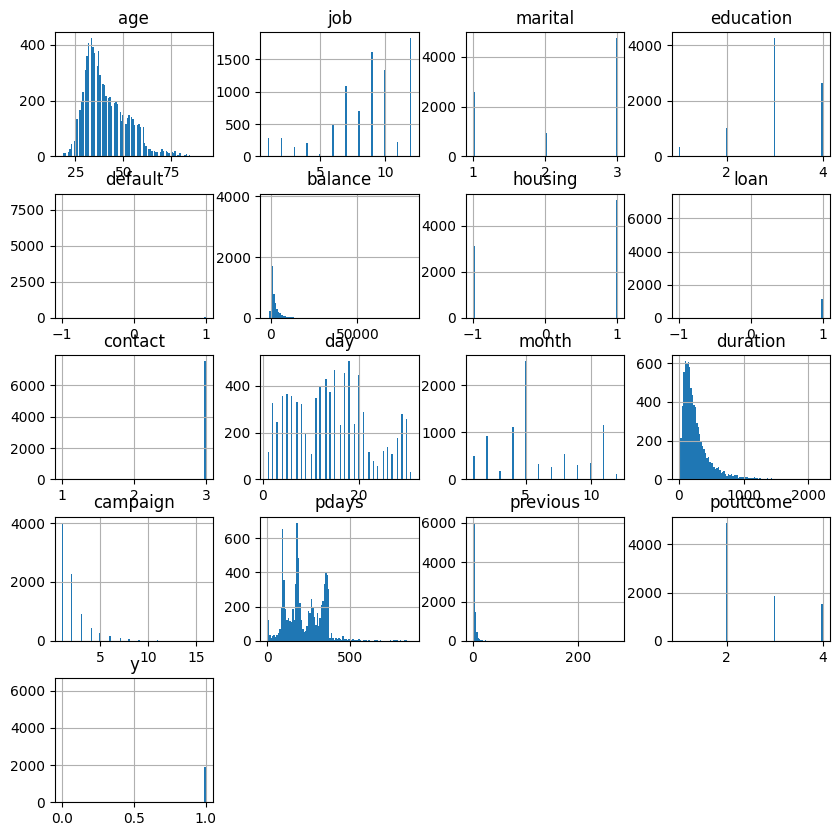

In [16]:
print('Lets see if the follow up of the client "pdays" changes something')
ax = Data[Data['pdays']>0].hist(figsize= (10,10),bins = 100)

In [34]:
Data.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

## Clean the categorial features
### First we select the columns that are string (objects)

In [6]:
Data.select_dtypes(include=['str']).T

,0,1,2,3,4,5,6,7,8,9,...,45201,45202,45203,45204,45205,45206,45207,45208,45209,45210
job,management,technician,entrepreneur,blue-collar,unknown,management,management,entrepreneur,retired,technician,...,management,admin.,student,retired,technician,technician,retired,retired,blue-collar,entrepreneur
marital,married,single,married,married,single,married,single,divorced,married,single,...,married,single,single,married,single,married,divorced,married,married,married
education,tertiary,secondary,secondary,unknown,unknown,tertiary,tertiary,tertiary,primary,secondary,...,tertiary,secondary,tertiary,secondary,secondary,tertiary,primary,secondary,secondary,secondary
default,no,no,no,no,no,no,no,yes,no,no,...,no,no,no,no,no,no,no,no,no,no
housing,yes,yes,yes,yes,no,yes,yes,yes,yes,yes,...,no,no,no,no,no,no,no,no,no,no
loan,no,no,yes,no,no,no,yes,no,no,no,...,no,no,no,no,yes,no,no,no,no,no
contact,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,...,cellular,cellular,cellular,cellular,cellular,cellular,cellular,cellular,telephone,cellular
month,may,may,may,may,may,may,may,may,may,may,...,nov,nov,nov,nov,nov,nov,nov,nov,nov,nov
poutcome,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,...,success,unknown,unknown,failure,unknown,unknown,unknown,success,unknown,other
y,no,no,no,no,no,no,no,no,no,no,...,yes,yes,yes,yes,yes,yes,yes,yes,no,no


In [7]:
StringColumns = Data.select_dtypes(include=['str']).columns.values
print(f'Columns that need a numerical coding: {StringColumns}')

Columns that need a numerical coding: <StringArray>
[      'job',   'marital', 'education',   'default',   'housing',      'loan',
   'contact',     'month',  'poutcome',         'y']
Length: 10, dtype: str


## Next we correct some of the features
###  Note the 'unique' method for DataFrames

In [8]:
TypesOfJobs = list(Data['job'].unique())
print(f'Types of Jobs:{TypesOfJobs}')
print()
print(f' Number of categories: {len(TypesOfJobs)}')

Types of Jobs:['management', 'technician', 'entrepreneur', 'blue-collar', 'unknown', 'retired', 'admin.', 'services', 'self-employed', 'unemployed', 'housemaid', 'student']

 Number of categories: 12


### As there is a relationship between salary and profesion we will introduce an adhoc code.

1.   Remember the use of the 'map' instruction.
2.   If you are interested in big data look for 'map-reduce'.

In [9]:
CodingJob = dict()
CodingJob['management'] = 12
CodingJob['technician'] = 10
CodingJob['entrepreneur'] = 11
CodingJob['blue-collar'] = 9
CodingJob['unknown'] = 5
CodingJob['retired'] = 6
CodingJob['admin.'] = 7
CodingJob['services'] = 8
CodingJob['self-employed'] = 1
CodingJob['unemployed'] = 4
CodingJob['housemaid'] = 3
CodingJob['student'] = 2
Data['job'] = Data['job'].map(CodingJob)

In [10]:
Default = dict()
Default['no'] = -1
Default['yes'] = +1
Data['default'] = Data['default'].map(Default)

###  We code the output 'y'

Remember we have a logistic regression as classifier:

$y = \frac{1}{1+e^{\beta^T X}}\longrightarrow$    Range: (0,1)

In [11]:
y = dict()
y['no'] = 0.
y['yes'] = +1.
Data['y'] = Data['y'].map(y)

In [12]:
MeanValue = Data['y'].mean()*100.
print(f' The proportion of yes: {MeanValue:2.2f} %')
print('Note that the classes are unbalanced. In theory we will see how to deal with this phenomenon')

 The proportion of yes: 11.70 %
Note that the classes are unbalanced. In theory we will see how to deal with this phenomenon



## Homework: <font color='red'> Do the same procedure for the rest of the categorical variables.</font>

## Homework: <font color='red'> Do an exploratory data analysis in order to understand the database.</font>  

# <font color='green'> Rest of the categorical variables ¿Best option?</font>

In [13]:
StringColumns = Data.select_dtypes(include=['str']).columns.values
print(f'Columns that need a numerical coding: {StringColumns}')
# TypesOfJobs = list(Data['month'].unique())
# print(f'Types of Jobs:{TypesOfJobs}')

Columns that need a numerical coding: <StringArray>
['marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']
Length: 7, dtype: str


In [14]:

Data_optimal = Data.copy()

# Revert the coding of the job column to apply one-hot encoding
reverse_job = {
    12: 'management',
    10: 'technician',
    11: 'entrepreneur',
    9: 'blue-collar',
    5: 'unknown',
    6: 'retired',
    7: 'admin.',
    8: 'services',
    1: 'self-employed',
    4: 'unemployed',
    3: 'housemaid',
    2: 'student'
}
Data_optimal['job'] = Data_optimal['job'].map(reverse_job)

# One hot encoding for the nominal columns
nominal_cols = ['job', 'marital', 'contact', 'poutcome', 'default']
Data_optimal = pd.get_dummies(Data_optimal, columns=nominal_cols)
bool_cols = Data_optimal.select_dtypes(include='bool').columns
Data_optimal[bool_cols] = Data_optimal[bool_cols].astype(int)

# Binary encoding for the binary columns
binary_map = {'yes': 1, 'no': 0}
for col in ['housing', 'loan']:
    Data_optimal[col] = Data_optimal[col].map(binary_map)

# Education (ordinal), beacuse we can assume that the levels of education have a natural order and relation with the target variable
edu_map = {'primary':1, 'secondary':2, 'tertiary':3, 'unknown':0}
Data_optimal['education'] = Data_optimal['education'].map(edu_map)

month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
             'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
Data_optimal['month_num'] = Data_optimal['month'].map(month_map)

Data_optimal['month_sin'] = np.sin(2*np.pi*Data_optimal['month_num']/12)
Data_optimal['month_cos'] = np.cos(2*np.pi*Data_optimal['month_num']/12)

# Day circular
Data_optimal['day_sin'] = np.sin(2*np.pi*Data_optimal['day']/31)
Data_optimal['day_cos'] = np.cos(2*np.pi*Data_optimal['day']/31)

print("\n=== ONE-HOT ENCODING ===")
# print(Data_optimal.T)
print(Data_optimal.dtypes)


=== ONE-HOT ENCODING ===
age                    int64
education              int64
balance                int64
housing                int64
loan                   int64
day                    int64
month                    str
duration               int64
campaign               int64
pdays                  int64
previous               int64
y                    float64
job_admin.             int64
job_blue-collar        int64
job_entrepreneur       int64
job_housemaid          int64
job_management         int64
job_retired            int64
job_self-employed      int64
job_services           int64
job_student            int64
job_technician         int64
job_unemployed         int64
job_unknown            int64
marital_divorced       int64
marital_married        int64
marital_single         int64
contact_cellular       int64
contact_telephone      int64
contact_unknown        int64
poutcome_failure       int64
poutcome_other         int64
poutcome_success       int64
poutcome_unknown 

In [15]:
Data_optimal = Data_optimal.select_dtypes(exclude=['object'])
# print(Data_optimal.dtypes)
print(Data_optimal.head().T)

                             0           1          2            3           4
age                  58.000000   44.000000  33.000000    47.000000   33.000000
education             3.000000    2.000000   2.000000     0.000000    0.000000
balance            2143.000000   29.000000   2.000000  1506.000000    1.000000
housing               1.000000    1.000000   1.000000     1.000000    0.000000
loan                  0.000000    0.000000   1.000000     0.000000    0.000000
day                   5.000000    5.000000   5.000000     5.000000    5.000000
duration            261.000000  151.000000  76.000000    92.000000  198.000000
campaign              1.000000    1.000000   1.000000     1.000000    1.000000
pdays                -1.000000   -1.000000  -1.000000    -1.000000   -1.000000
previous              0.000000    0.000000   0.000000     0.000000    0.000000
y                     0.000000    0.000000   0.000000     0.000000    0.000000
job_admin.            0.000000    0.000000   0.00000

# <font color='green'> Rest of the categorical variables as the professor has done.</font>

In [14]:
StringColumns = Data.select_dtypes(include=['str']).columns.values
print(f'Columns that need a numerical coding: {StringColumns}')
# # TypesOfJobs = list(Data['month'].unique())
# # print(f'Types of Jobs:{TypesOfJobs}')

CodingMarital = dict()
CodingMarital['married'] = 3
CodingMarital['single'] = 1
CodingMarital['divorced'] = 2
Data['marital'] = Data['marital'].map(CodingMarital)

CodingEducation = dict()
CodingEducation['unknown'] = 1
CodingEducation['secondary'] = 3
CodingEducation['tertiary'] = 4
CodingEducation['primary'] = 2
Data['education'] = Data['education'].map(CodingEducation)

CodingHousing = dict()
CodingHousing['yes'] = +1
CodingHousing['no'] = -1
Data['housing'] = Data['housing'].map(CodingHousing)

CodingLoan = dict()
CodingLoan['yes'] = +1
CodingLoan['no'] = -1
Data['loan'] = Data['loan'].map(CodingLoan)

CodingContact = dict()
CodingContact['unknown'] = 1
CodingContact['telephone'] = 2
CodingContact['cellular'] = 3
Data['contact'] = Data['contact'].map(CodingContact)

CodingPoutcome = dict()
CodingPoutcome['unknown'] = 1
CodingPoutcome['failure'] = 2
CodingPoutcome['other'] = 3
CodingPoutcome['success'] = 4
Data['poutcome'] = Data['poutcome'].map(CodingPoutcome)

CodingMonth = dict()
CodingMonth['jan'] = 1
CodingMonth['feb'] = 2
CodingMonth['mar'] = 3
CodingMonth['apr'] = 4
CodingMonth['may'] = 5
CodingMonth['jun'] = 6
CodingMonth['jul'] = 7
CodingMonth['aug'] = 8
CodingMonth['sep'] = 9
CodingMonth['oct'] = 10
CodingMonth['nov'] = 11
CodingMonth['dec'] = 12
Data['month'] = Data['month'].map(CodingMonth)

print(f'Data types after coding: \n{Data.dtypes}')


Columns that need a numerical coding: <StringArray>
['marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']
Length: 7, dtype: str
Data types after coding: 
age            int64
job            int64
marital        int64
education      int64
default        int64
balance        int64
housing        int64
loan           int64
contact        int64
day            int64
month          int64
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome       int64
y            float64
dtype: object


# <font color='green'> Exploratory data analysis in order to understand the database.</font>

In [17]:
print("=== ANALISIS DE VALORES UNKNOWN ===\n")

unknown_map = {
    'job': 5,
    'education': 1,
    'contact': 1,
    'poutcome': 1
}

for col, val in unknown_map.items():
    total = len(Data)
    unknown_count = (Data[col] == val).sum()
    percentage = 100 * unknown_count / total  
    print(f"{col}:")
    print(f"  Unknowns: {unknown_count} ({percentage:.2f}%)")

### Si hay muchos unknown comentar: Puede introducir ruido Puede sesgar el modelo Se puede: eliminar tratar como categoría propia imputar

=== ANALISIS DE VALORES UNKNOWN ===

job:
  Unknowns: 288 (0.64%)
education:
  Unknowns: 1857 (4.11%)
contact:
  Unknowns: 13020 (28.80%)
poutcome:
  Unknowns: 36959 (81.75%)


In [18]:
print("=== ANALISIS DE LA VARIABLE OBJETIVO (y) ===\n")

print(Data['y'].value_counts())
print("\nPorcentajes:")
print(Data['y'].value_counts(normalize=True) * 100)

### Comentar si el dataset esta balanceado o no. En este caso no lo esta, lo que puede afectar al rendimiento del modelo. Se pueden aplicar técnicas de balanceo como oversampling o undersampling.

=== ANALISIS DE LA VARIABLE OBJETIVO (y) ===

y
0.0    39922
1.0     5289
Name: count, dtype: int64

Porcentajes:
y
0.0    88.30152
1.0    11.69848
Name: proportion, dtype: float64



## 1. ANÁLISIS DE VARIABLES NUMÉRICAS

### Observaciones de los histogramas y estadísticas descriptivas:

*a) Age (Edad)*
- Distribución relativamente uniforme entre 30-60 años, tener en cuenta que los jovenes tienen menos ahorros y más riesgo en cambio las personas mayores suelen ser más conservadoras.

*b) Balance (Saldo anual promedio)*
- Problema grabe relacionado con los outliers, tienen muchos, tener en cuenta que contra más dinero más capacidad de invertir.

*c) Duration (Duración de la llamada)*
- Esta variables es trampa, ya que no se conoce hasta despues de realizar la llamada, como podemos ver luego tiene una mayor correlación con la salida que otras variables pero es falsa.

*d) Campaign (Número de contactos en esta campaña)*
- Mayoría de clientes enter 1-3 contactos, tener en cuenta clientes muy llamados es posible que tengan desinteres.

*e) Pdays (Días desde último contacto previo9*
- Valor -1 predominante: cliente NO fue contactado previamente. Cuando pdays > 0, la distribución cambia significativamente

*f) Previous (Contactos previos)*
- Mayoría: 0 contactos previos

---

## 2. ANÁLISIS DE VARIABLES CATEGÓRICAS

*a) Job (Profesión)*
- Variable relevante, ya que indica el nivel econoómico de una persona y su estavilidad.

*b) Marital (Estado civil)*
- Married predomina y debemos tener en cuenta que tienen mayor estabildiad financiera.

*c) Education (Nivel educativo)*
- Relacionado con job y capacidad económica-

*d) Default (Crédito en default)*
- Muy desbalanceado, además si tienen deudas la probabilidad de invertir es muy baja.

*e) Housing & Loan*
- Son indicadores de compromiso financiero pero peuden mostrar poca liquidez.

*f) Contact (Tipo de contacto)*
- Poco relevante

*g) Month (Mes del contacto)*
- Puede haber estacionalidad

*h) Poutcome (Resultado campaña anterior)*
- Importante para predecir, si la campaña anterior fue buena es posible que esta tambien

---

## 3. ANÁLISIS DE LA VARIABLE OBJETIVO (y)

- Problema grave con el desbalanceo, demasiados No en la base de datos, se pude ver afectada la predicción al no tener un dataset equilibrado.

---

## 4. ANÁLISIS DE CORRELACIONES

# *Correlaciones importantes observadas en la matriz:*

## Correlaciones POSITIVAS con target (y):
- *duration* (0.4): TRAMPA
- *poutcome*: Resultado previo success
- *previous*: Número de contactos previos exitosos
- *housing = no*: No tener hipoteca favorece suscripción

## Correlaciones NEGATIVAS con target (y):
- *housing = yes*: Tener hipoteca reduce probabilidad
- Alta frecuencia de contactos (campaign)

## Multicolinealidad detectada:
- *day - month*: Variables temporales relacionadas
- *previous - pdays*: Ambas miden contacto previo
- *job - education*: Correlación socioeconómica
- *balance - job*: Nivel económico


In [ ]:
# VISUALIZACIONES ADICIONALES PARA EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ANÁLISIS EXPLORATORIO - DISTRIBUCIONES CLAVE', fontsize=16, fontweight='bold')

# 1. Distribución de Age
ax1 = axes[0, 0]
Data['age'].hist(bins=30, ax=ax1, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(Data['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {Data["age"].mean():.1f}')
ax1.axvline(Data['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {Data["age"].median():.1f}')
ax1.set_xlabel('Edad', fontweight='bold')
ax1.set_ylabel('Frecuencia', fontweight='bold')
ax1.set_title('Distribución de Edad')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Balance - Problema de escala
ax2 = axes[0, 1]
Data['balance'].hist(bins=100, ax=ax2, color='orange', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Balance (€)', fontweight='bold')
ax2.set_ylabel('Frecuencia', fontweight='bold')
ax2.set_title('Balance - Distribución SESGADA (outliers)')
ax2.grid(alpha=0.3)
ax2.text(0.95, 0.95, 'PROBLEMA:\nEscala muy amplia\nOutliers dominan', 
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 3. Duration - Variable trampa
ax3 = axes[1, 0]
Data['duration'].hist(bins=100, ax=ax3, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Duración (segundos)', fontweight='bold')
ax3.set_ylabel('Frecuencia', fontweight='bold')
ax3.set_title('Duration - VARIABLE TRAMPA (Data Leakage)')
ax3.grid(alpha=0.3)
ax3.text(0.95, 0.95, '⚠ WARNING:\nSolo disponible\nDESPUÉS de llamada', 
         transform=ax3.transAxes, fontsize=10, verticalalignment='top',
         horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

# 4. Campaign - Número de contactos
ax4 = axes[1, 1]
campaign_counts = Data['campaign'].value_counts().sort_index()
campaign_counts[campaign_counts.index <= 20].plot(kind='bar', ax=ax4, color='steelblue', alpha=0.7)
ax4.set_xlabel('Número de contactos en campaña', fontweight='bold')
ax4.set_ylabel('Frecuencia', fontweight='bold')
ax4.set_title('Campaign - Mayoría: 1-3 contactos')
ax4.grid(alpha=0.3, axis='y')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("\n✅ Visualizaciones generadas correctamente")
print("📊 Observa las diferencias de escala y distribuciones sesgadas")


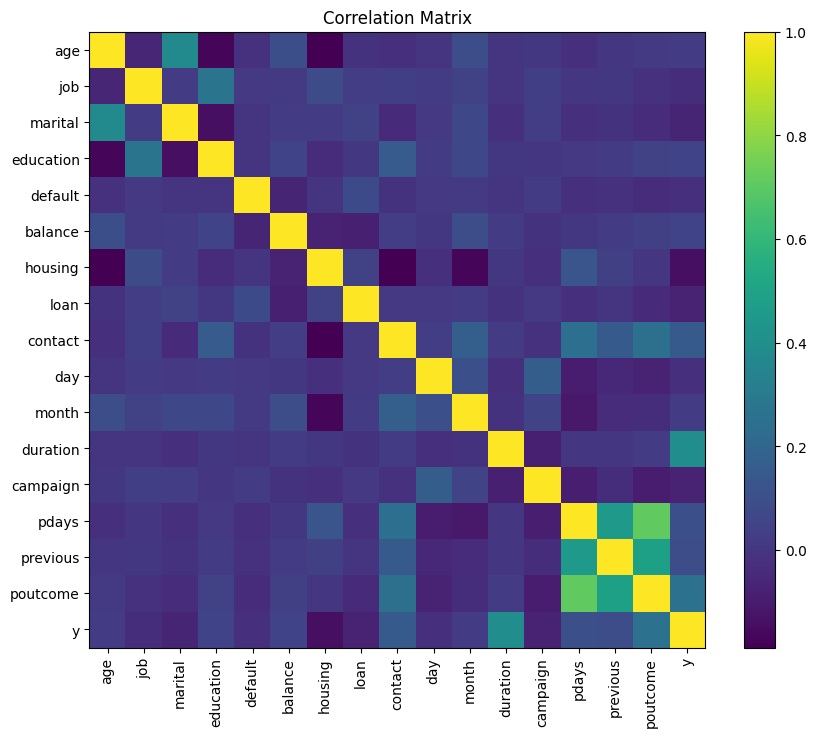

In [22]:
corr = Data.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

###  We delete the columns that have not been used

In [23]:
Data = Data.select_dtypes(exclude=['object'])

In [24]:
Data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
job,45211.0,8.63,2.85,1.0,7.0,9.0,10.0,12.0
marital,45211.0,2.32,0.88,1.0,1.0,3.0,3.0,3.0
education,45211.0,3.06,0.78,1.0,3.0,3.0,4.0,4.0
default,45211.0,-0.96,0.27,-1.0,-1.0,-1.0,-1.0,1.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211.0,0.11,0.99,-1.0,-1.0,1.0,1.0,1.0
loan,45211.0,-0.68,0.73,-1.0,-1.0,-1.0,-1.0,1.0
contact,45211.0,2.36,0.90,1.0,1.0,3.0,3.0,3.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0


### Scatter plot with a color per class

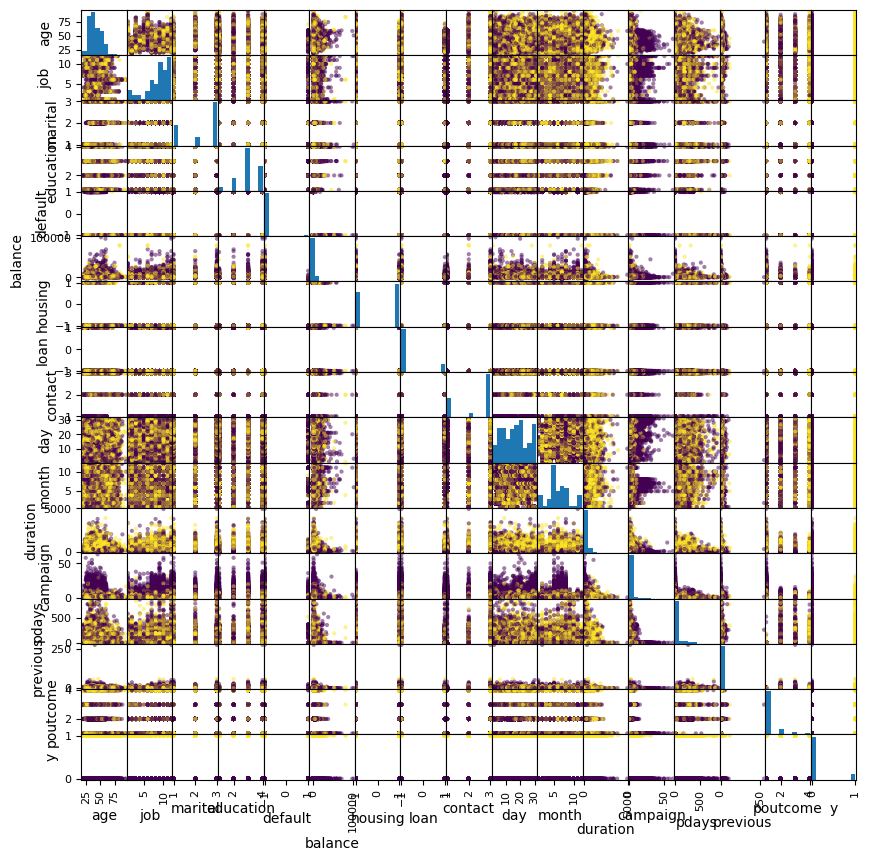

In [ ]:
if False:
    ax = pd.plotting.scatter_matrix(Data,c =Data['y'], figsize = (10,10))
    for a in ax.ravel():
        a.set_xlabel(a.get_xlabel(), rotation=45)
        a.set_ylabel(a.get_ylabel(), rotation=0)

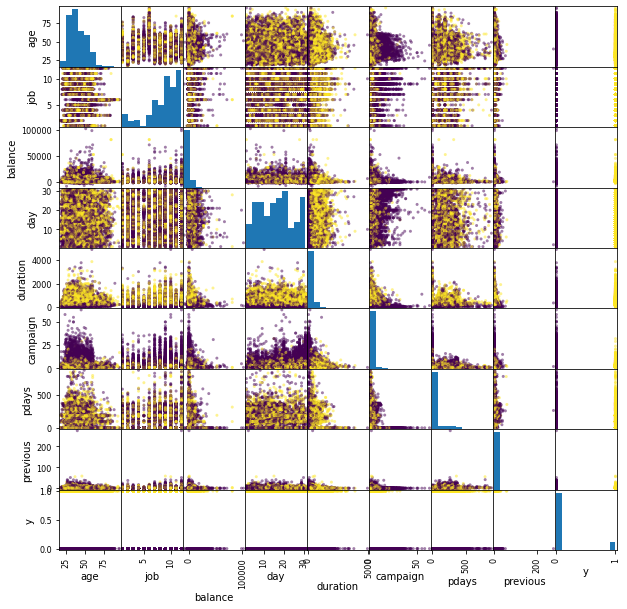

# <font color='green'> Scatter plot para variables optimizadas </font> 

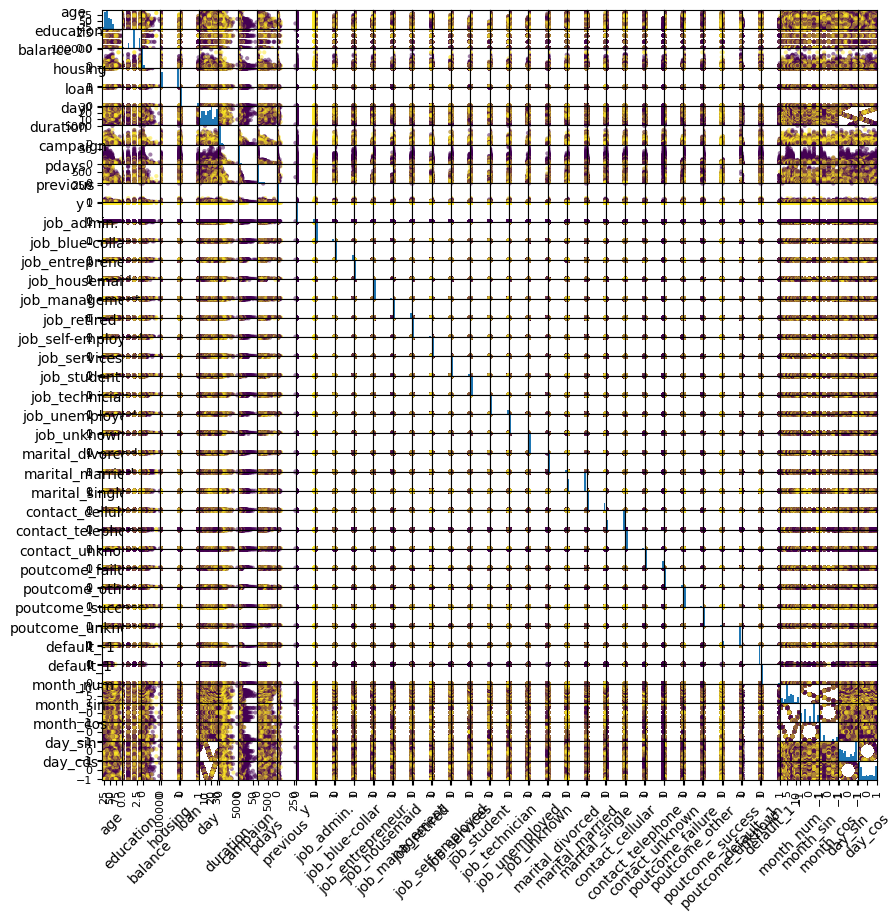

In [108]:
if True:
    ax = pd.plotting.scatter_matrix(Data_optimal,c =Data_optimal['y'], figsize = (10,10))
    for a in ax.ravel():
        a.set_xlabel(a.get_xlabel(), rotation=45)
        a.set_ylabel(a.get_ylabel(), rotation=0)

## We do the partition in training and testing data.

### We will use a helper function

In [25]:
def PartitionOfDatabase(Data,Fraction = 0.75):
    NumSamples, NumFeatures = Data.shape
    Index = list(range(NumSamples))
    RandomIndex = np.random.permutation(Index)
    NumTrainElements = int(Fraction*NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB = Data.iloc[TrainIndex]
    TestDB = Data.iloc[TestIndex]
    return TrainDB,TestDB

In [26]:
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)

In [27]:
print('Next we correct the data types')
TrainDB.dtypes

Next we correct the data types


age            int64
job            int64
marital        int64
education      int64
default        int64
balance        int64
housing        int64
loan           int64
contact        int64
day            int64
month          int64
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome       int64
y            float64
dtype: object

In [28]:
TrainDB = TrainDB.astype('float')
TestDB = TestDB.astype('float')

### Lets try a logistic classifier

In [29]:
y = TrainDB['y']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'y']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']
__________________________________________________


In [30]:
logreg = LogisticRegression(solver='newton-cg',penalty = 'l2',C=10,max_iter = 1000,fit_intercept = True)
logreg.fit(X, y)

c:\Users\Marcel\Uni\Master\MLEARN\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 


## Homework: <font color='red'>Explain a strategy of classification by reading the coefficients, which is the relationship between the meaning of each variable (and statistical distribution), its sign and the absolute value</font>


## Homework: <font color='green'>Explain a strategy of classification by reading the coefficients, which is the relationship between the meaning of each variable (and statistical distribution), its sign and the absolute value</font>

Segun los valores obtenidos con la regresión logística podemos suponer que la estreategia de clasificación será en función de los coeficientes más grandes, los cuales son los siguientes:
- poutcome: Como podiamos suponer, si la campaña anterior ha ido bien esta tambíen lo irá, de tal manera que es un muy buen indicador. Aunque debemos tener en cuenta que es una variable con muchos unknowns.
- contact: Parece tener una gran relación, aunque no debería ser relevante, además que igual que con poutcome tambíen tieen varios unknowns.
- hosuing: Como habiamos estimado tiene una relación inversa con 'y', debido a que si la persona tiene una hipoteca es probable que no tenga demasiada liquidez.
- loan: Como habíamos supuesto tiene una relación negativa, el caso es muy similar al de housing.

---
## 📊 RESPUESTA COMPLETA Y MEJORADA

### **⚠️ PROBLEMA CRÍTICO: Los coeficientes están distorsionados por la escala**

Al observar el gráfico de coeficientes, vemos que `balance` y `duration` tienen valores ~0.00001, **NO porque sean irrelevantes**, sino porque tienen rangos enormes:
- `balance`: [-8,000 a +102,000]
- `duration`: [0 a 4,918 segundos]

En cambio, `poutcome` y `contact` tienen coeficientes grandes porque sus rangos son pequeños (1-4 y 1-3 respectivamente).

---

### **1. SIGNO del coeficiente** → Indica la dirección de la relación

#### Coeficientes POSITIVOS (+) → Aumentan probabilidad de suscripción (y=1):
- **poutcome** (+): Éxito en campaña anterior predice éxito actual → **mejor indicador legítimo**
- **contact** (+): Cellular (valor 3) favorece más que telephone o unknown
- **previous** (+): Más contactos previos exitosos → más interés del cliente
- **duration** (+): Llamadas largas → interés (**⚠️ TRAMPA: solo se conoce después de la llamada**)

#### Coeficientes NEGATIVOS (-) → Reducen probabilidad de suscripción:
- **housing** (-): Tener hipoteca (yes = +1) reduce liquidez disponible
- **loan** (-): Tener préstamo personal reduce capacidad de inversión  
- **campaign** (-): Muchos contactos → cliente saturado/molesto/desinteresado
- **balance** (-): Aparece negativo por problemas de escala (se corregirá con normalización)

---

### **2. MAGNITUD del coeficiente** → ¡CUIDADO! No indica importancia real aquí

**Por qué la magnitud es engañosa:**

Variables con **rango pequeño** → coeficientes GRANDES:
- `poutcome` (1-4): coef ≈ 0.5
- `contact` (1-3): coef ≈ 0.3

Variables con **rango grande** → coeficientes MINÚSCULOS:
- `balance` (-8000 a +102000): coef ≈ 0.00001
- `duration` (0 a 4918): coef ≈ 0.00001

**Ejemplo numérico de por qué esto confunde:**

Para un cliente con:
- `balance = 50,000€` y `coef_balance = 0.00001`  
  → Contribución al logit = 50,000 × 0.00001 = **0.5**

- `poutcome = 4 (success)` y `coef_poutcome = 0.5`  
  → Contribución al logit = 4 × 0.5 = **2.0**

Ambas variables contribuyen al modelo, aunque sus coeficientes parezcan muy diferentes.

---

### **3. Estrategia de clasificación del modelo**

El modelo predice **YES (y=1)** para clientes con el siguiente perfil:

✅ **Factores que favorecen suscripción:**
- Éxito en campaña anterior (`poutcome = 4`)
- Contacto por cellular (`contact = 3`)
- **SIN** hipoteca (`housing = -1`)
- **SIN** préstamo personal (`loan = -1`)
- Pocos contactos en campaña actual (`campaign` bajo, ej: 1-2)
- Balance positivo y alto
- Duración de llamada larga (pero es trampa)

❌ **Factores que desfavorecen suscripción:**
- Fracaso en campaña anterior (`poutcome = 2`)
- Muchos contactos sin éxito (`campaign` alto, ej: >5)
- Tener hipoteca Y préstamo (compromiso financiero alto)
- Balance negativo o muy bajo

---

### **4. Por qué el gráfico de barras nos engaña**

**Lo que PARECE al ver el gráfico:**
- `poutcome`, `contact`, `job` → dominantes (coeficientes grandes)
- `balance`, `duration` → irrelevantes (coeficientes minúsculos)

**La REALIDAD:**
- ✅ `poutcome` **SÍ es realmente importante** (correlación con target)
- ⚠️ `contact` **parece importante solo por su escala pequeña** (1-3)
- ⚠️ `job` **parece importante solo por su escala pequeña** (1-12)
- ❌ `balance` y `duration` **NO son irrelevantes**, solo tienen escala enorme

**Para saber la importancia REAL necesitamos normalizar con StandardScaler.**

---

### **5. Relación entre distribución estadística y coeficientes**

- **Variables con distribución sesgada** (balance, duration) → transformación logarítmica ya aplicada más adelante
- **Variables con outliers** (balance) → afectan la estimación del coeficiente
- **Variables desbalanceadas** (default: 95% no) → poco poder discriminativo
- **Variables con muchos "unknown"** (poutcome: 80%) → ruido en la estimación

---

### **CONCLUSIÓN CLAVE**

**Sin normalización (StandardScaler), NO podemos comparar la importancia de variables con escalas diferentes.**

Un coeficiente grande puede pertenecer a una variable poco importante que simplemente tiene rango pequeño (ej: mes del año 1-12), y un coeficiente pequeño puede ser de una variable muy importante con rango grande (ej: balance en euros).

**Por eso el profesor menciona que más adelante veremos StandardScaler**, que pone todas las variables en media=0 y desviación=1, permitiendo comparar coeficientes de forma justa y entender qué variables son verdaderamente importantes para predecir la suscripción del depósito.

---

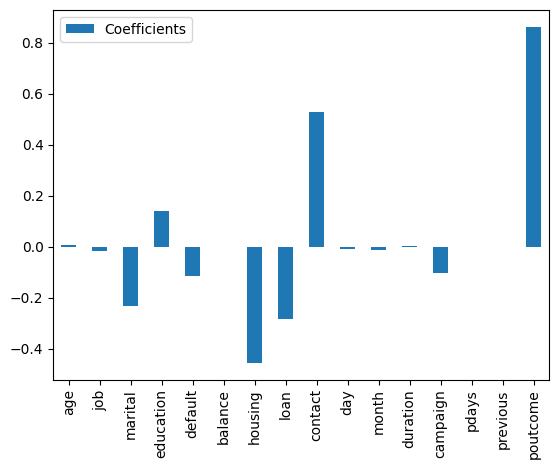

In [31]:
Features = X.columns
df = pd.DataFrame(data = logreg.coef_.T, index = Features, columns = ['Coefficients'] )
ax = df.plot.bar()

In [32]:
print('WHY. Hint')
Data.describe().T

WHY. Hint


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211.0,8.631771,2.847568,1.0,7.0,9.0,10.0,12.0
marital,45211.0,2.319037,0.884908,1.0,1.0,3.0,3.0,3.0
education,45211.0,3.060516,0.778704,1.0,3.0,3.0,4.0,4.0
default,45211.0,-0.963947,0.266098,-1.0,-1.0,-1.0,-1.0,1.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211.0,0.111676,0.993756,-1.0,-1.0,1.0,1.0,1.0
loan,45211.0,-0.679547,0.733640,-1.0,-1.0,-1.0,-1.0,1.0
contact,45211.0,2.359758,0.897951,1.0,1.0,3.0,3.0,3.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


###  Method sensitive to the scale of the dataa
####  Further in the course we will see a better way of solving this problem (hint: look at from sklearn.preprocessing import StandardScaler)

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.000000,33.000000,39.000000,48.000000,95.000000
job,45211.0,8.631771,2.847568,1.000000,7.000000,9.000000,10.000000,12.000000
default,45211.0,-0.963947,0.266098,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
balance,45211.0,1362.272058,3044.765829,-8019.000000,72.000000,448.000000,1428.000000,102127.000000
day,45211.0,15.806419,8.322476,1.000000,8.000000,16.000000,21.000000,31.000000
duration,45211.0,5.171812,0.921822,0.000000,4.644391,5.198497,5.768321,8.500861
campaign,45211.0,2.763841,3.098021,1.000000,1.000000,2.000000,3.000000,63.000000
pdays,45211.0,40.197828,100.128746,-1.000000,-1.000000,-1.000000,-1.000000,871.000000
previous,45211.0,0.580323,2.303441,0.000000,0.000000,0.000000,0.000000,275.000000
y,45211.0,0.116985,0.321406,0.000000,0.000000,0.000000,0.000000,1.000000


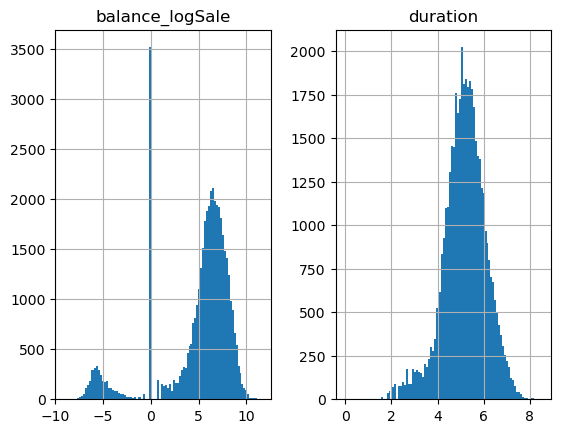

In [35]:
Data['balance_logSale'] = np.log(np.abs(Data['balance'])+1)*np.sign(Data['balance'])
Data['duration'] = np.log(Data['duration']+1)
Data[['balance_logSale','duration']].hist(bins = 100)
Data.describe().T

##  Now we have two gaussians !!!!

### We update the database

In [36]:
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)
TrainDB = TrainDB.astype('float')
TestDB = TestDB.astype('float')
y = TrainDB['y']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'y']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['age', 'job', 'default', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'balance_logSale']
__________________________________________________


In [37]:
logreg = LogisticRegression(solver='newton-cg',penalty = 'l2',C=1,max_iter = 1000,fit_intercept = True)
logreg.fit(X, y)

LogisticRegression(C=1, max_iter=1000, solver='newton-cg')

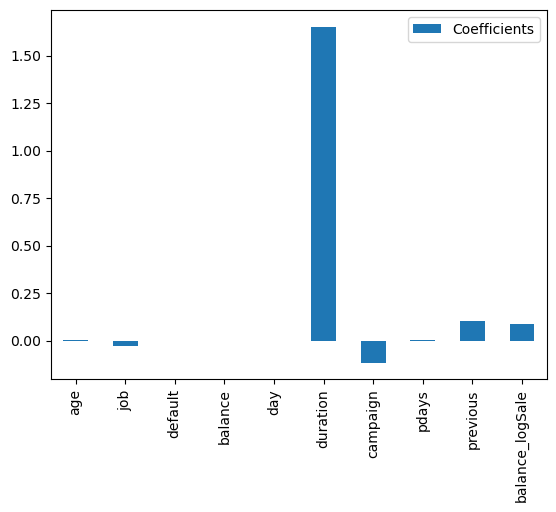

In [38]:
Features = X.columns
df = pd.DataFrame(data = logreg.coef_.T, index = Features, columns = ['Coefficients'] )
ax = df.plot.bar()


## Homework: <font color='red'>Explain what has happened. Why irrelevant variables in one scale are important in another scale</font>

## Performance index: Accuracy score

**Definition:**
$\texttt{accuracy}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples}-1} 1(\hat{y}_i = y_i)$

**Note:** There are more performance indices. We will see them further in the course.

Accuracy (train)  88.9% 
[[29423   508]
 [ 3272   705]]


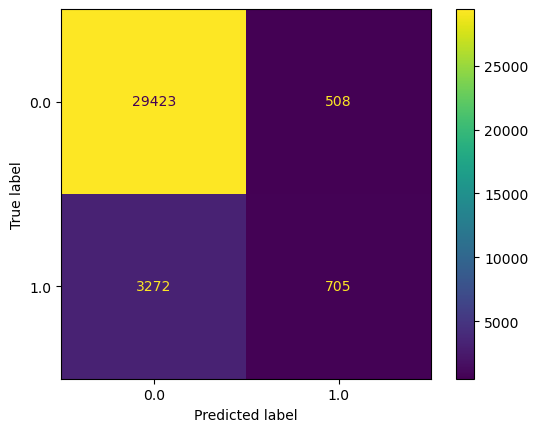

In [39]:

y_hat = logreg.predict(X)
accuracy = accuracy_score(y, y_hat)
print("Accuracy (train)  %0.1f%% " % ( accuracy * 100))
print(confusion_matrix(y, y_hat))
ConfusionMatrixDisplay.from_estimator(logreg, X, y)
plt.show()


## Homework: <font color='red'>Compute the accuracy in the test database</font>

## Homework: <font color='red'>Compute the performance in the initial model with the variables in linear scale</font>

## Homework: <font color='red'>Do some feature engineering for improving the performance. Try to justify the feature engineering from your understanding of the problem, i.e. common sense and probability distributions</font>


## Cross-validation to find the optimal C parameter

The C parameter in Logistic Regression is the inverse of the regularization strength. We will use cross-validation to find the optimal C value that maximizes accuracy.


In [40]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import KFold

# Define the range of C values to test
C_values = np.logspace(-3, 3, 50)

# Create LogisticRegressionCV to find optimal C using cross-validation
logreg_cv = LogisticRegressionCV(Cs=C_values, cv=5, solver='newton-cg', 
                                   penalty='l2', max_iter=1000, fit_intercept=True, 
                                   scoring='accuracy')

# Prepare fresh training data
TrainDB_cv, TestDB_cv = PartitionOfDatabase(Data, Fraction=0.75)
TrainDB_cv = TrainDB_cv.astype('float')
TestDB_cv = TestDB_cv.astype('float')
y_train = TrainDB_cv['y']
X_train = TrainDB_cv[InputFeatures]
y_test = TestDB_cv['y']
X_test = TestDB_cv[InputFeatures]

# Fit the model with cross-validation
logreg_cv.fit(X_train, y_train)

# Get the optimal C
optimal_C = logreg_cv.C_[0]
print(f"Optimal C parameter found by cross-validation: {optimal_C:.4f}")
print(f"Cross-validation scores: {logreg_cv.scores_[1].mean():.4f} (+/- {logreg_cv.scores_[1].std():.4f})")


Optimal C parameter found by cross-validation: 0.1207
Cross-validation scores: 0.8861 (+/- 0.0016)


### Performance on Training Database


Accuracy (train)  88.7% 
[[29430   491]
 [ 3353   634]]


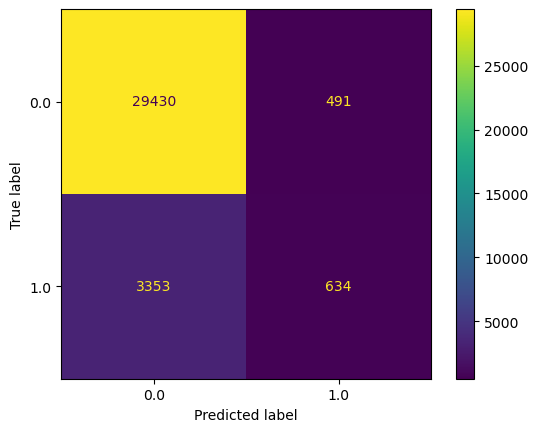

In [41]:
y_hat_train = logreg_cv.predict(X_train)
accuracy_train = accuracy_score(y_train, y_hat_train)
print("Accuracy (train)  %0.1f%% " % (accuracy_train * 100))
print(confusion_matrix(y_train, y_hat_train))
ConfusionMatrixDisplay.from_estimator(logreg_cv, X_train, y_train)
plt.show()


### Performance on Test Database


Accuracy (test)  89.1% 
[[9846  155]
 [1077  225]]


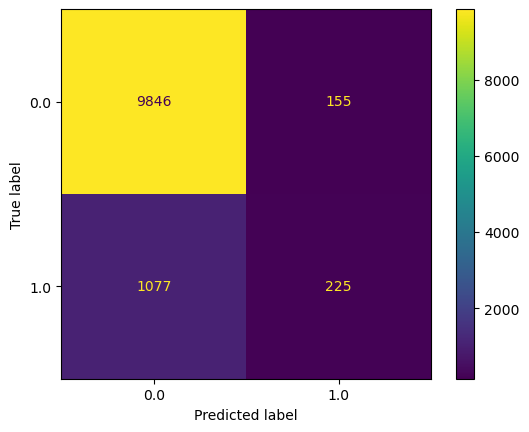

In [42]:
y_hat_test = logreg_cv.predict(X_test)
accuracy_test = accuracy_score(y_test, y_hat_test)
print("Accuracy (test)  %0.1f%% " % (accuracy_test * 100))
print(confusion_matrix(y_test, y_hat_test))
ConfusionMatrixDisplay.from_estimator(logreg_cv, X_test, y_test)
plt.show()


 ### Excercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear.

### Excercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.


# Appendix: Description of the database

### For more information, read [Moro et al., 2011].

   Input variables:
   ### bank client data:
   1 - age (numeric)
   
   2 - job : type of job (categorical: 
   "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services") 
                                       
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
   
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   
   5 - default: has credit in default? (binary: "yes","no")
   
   6 - balance: average yearly balance, in euros (numeric) 
   
   7 - housing: has housing loan? (binary: "yes","no")
   
   8 - loan: has personal loan? (binary: "yes","no")
   
   ### related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")
   
  10 - day: last contact day of the month (numeric)
  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  
  12 - duration: last contact duration, in seconds (numeric)
  
   # other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")
  

  ## Output variable (desired target):
  
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")